In [63]:
# Python ≥3.5 is required
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

import os
import pandas as pd
from pandas.plotting import scatter_matrix
import numpy as np 
from pathlib import Path

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "end_to_end_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)
import tarfile
import urllib.request

In [64]:
f = "datasets/housing/housing_data.csv" 
housing = pd.read_csv(f)

In [65]:
import pandas as pd

def muestrear_columna(df: pd.DataFrame, columna: str, porcentaje: float, replace: bool = True) -> pd.Series:
    """
    Realiza un muestreo aleatorio sobre una columna específica de un DataFrame de pandas.

    Parámetros:
    - df (pd.DataFrame): DataFrame de entrada.
    - columna (str): Nombre de la columna a muestrear.
    - porcentaje (float): Porcentaje de elementos a tomar, expresado como decimal (ej. 0.1 para 10%).
    - replace (bool): Si True, se realiza con reemplazo. Si False, sin reemplazo.

    Retorna:
    - pd.Series: Serie con los elementos muestreados.
    
    Requiere:
    - pandas importado como pd.
    """
    if columna not in df.columns:
        raise ValueError(f"La columna '{columna}' no existe en el DataFrame.")

    total_filas = len(df)
    muestra_n = int(total_filas * porcentaje)

    if not replace and muestra_n > total_filas:
        raise ValueError("No se puede tomar una muestra sin reemplazo mayor al total de filas.")

    return df[columna].sample(n=muestra_n, replace=replace, random_state=42).reset_index(drop=True)


In [66]:
from typing import Callable, List
import pandas as pd

def simular_promedios_muestrales(
    df: pd.DataFrame,
    columna: str,
    porcentaje: float,
    repeticiones: int,
    funcion_muestreo: Callable[[pd.DataFrame, str, float, bool], pd.Series],
    replace: bool = True
) -> List[float]:
    """
    Simula el Teorema Central del Límite repitiendo un muestreo aleatorio varias veces
    y calculando el promedio de cada muestra.

    Parámetros:
    - df (pd.DataFrame): DataFrame de entrada.
    - columna (str): Nombre de la columna a muestrear.
    - porcentaje (float): Porcentaje de la población a tomar en cada muestra (ej. 0.1 para 10%).
    - repeticiones (int): Número de repeticiones del experimento.
    - funcion_muestreo (Callable): Función de muestreo que retorna una Serie (como `muestrear_columna`).
    - replace (bool): Define si se usa muestreo con reemplazo.

    Retorna:
    - List[float]: Lista con los promedios de cada muestra.
    """
    promedios = []
    for _ in range(repeticiones):
        muestra = funcion_muestreo(df, columna, porcentaje, replace)
        promedio = muestra.mean()
        promedios.append(promedio)
    return promedios


In [67]:
housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [68]:
col = "median_house_value"

In [73]:
data = simular_promedios_muestrales(housing, col, .3, 1000, muestrear_columna)

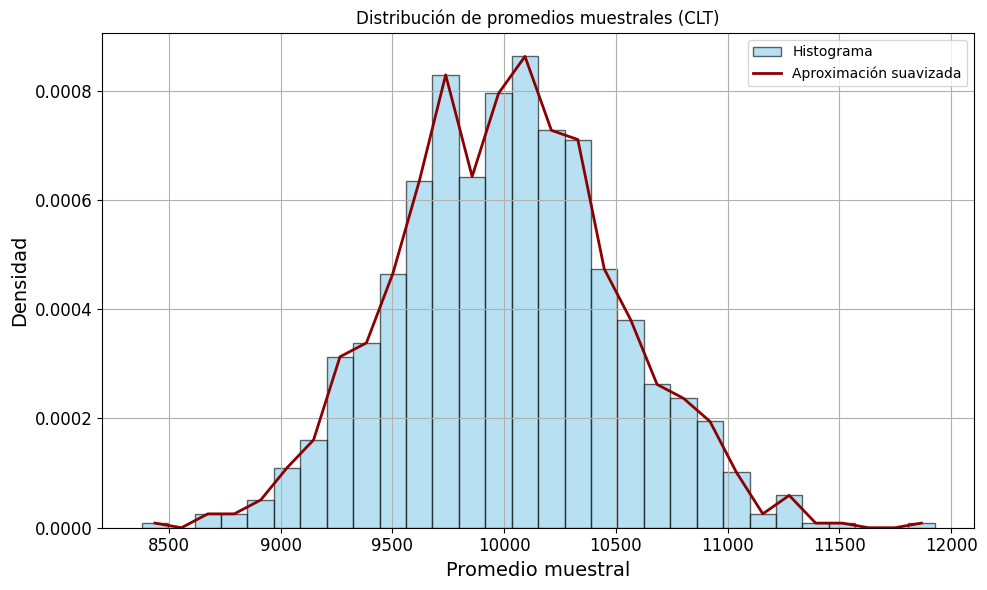

In [71]:
import numpy as np
import matplotlib.pyplot as plt

# Suponiendo que ya tienes esta lista generada:
# promedios_simulados = [resultado de simular_promedios_muestrales(...)]
# Aquí usamos un ejemplo simulado:
np.random.seed(42)
promedios_simulados = np.random.normal(loc=10000, scale=500, size=1000)

# Crear histograma (frecuencias relativas)
counts, bins = np.histogram(promedios_simulados, bins=30, density=True)

# Calcular puntos medios de los bins para graficar la línea
bin_centers = 0.5 * (bins[1:] + bins[:-1])

# Graficar
plt.figure(figsize=(10, 6))

# Histograma
plt.hist(promedios_simulados, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Histograma')

# Línea de densidad aproximada (conectando los puntos medios del histograma)
plt.plot(bin_centers, counts, color='darkred', linewidth=2, label='Aproximación suavizada')

# Estética
plt.title('Distribución de promedios muestrales (CLT)')
plt.xlabel('Promedio muestral')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [75]:
def generar_lista_promedios(
    df: pd.DataFrame,
    porcentaje: float,
    iteraciones: int,
    columna: str,
    replace: bool = True
) -> list:
    """
    Realiza un proceso de muestreo repetido sobre una columna numérica de un DataFrame 
    y devuelve una colección de valores promedio, uno por iteración.

    Parámetros:
    - df (pd.DataFrame): Conjunto de datos que contiene la columna objetivo.
    - porcentaje (float): Proporción del total de observaciones a incluir en cada muestra (por ejemplo, 0.1 equivale al 10%).
    - iteraciones (int): Número total de veces que se repetirá el proceso de muestreo.
    - columna (str): Nombre de la columna numérica sobre la cual se calcularán los promedios.
    - replace (bool): Indica si el muestreo se realiza con reemplazo (True) o sin reemplazo (False).

    Retorna:
    - list: Lista de valores promedios resultantes de cada iteración del proceso de muestreo.
    """
    n = int(len(df) * porcentaje)
    promedios = []
    for _ in range(iteraciones):
        muestra = df[columna].sample(n=n, replace=replace)
        promedios.append(muestra.mean())
    return promedios


In [79]:
col = "median_house_value"
a = generar_lista_promedios(housing, .3, 200, col, False)

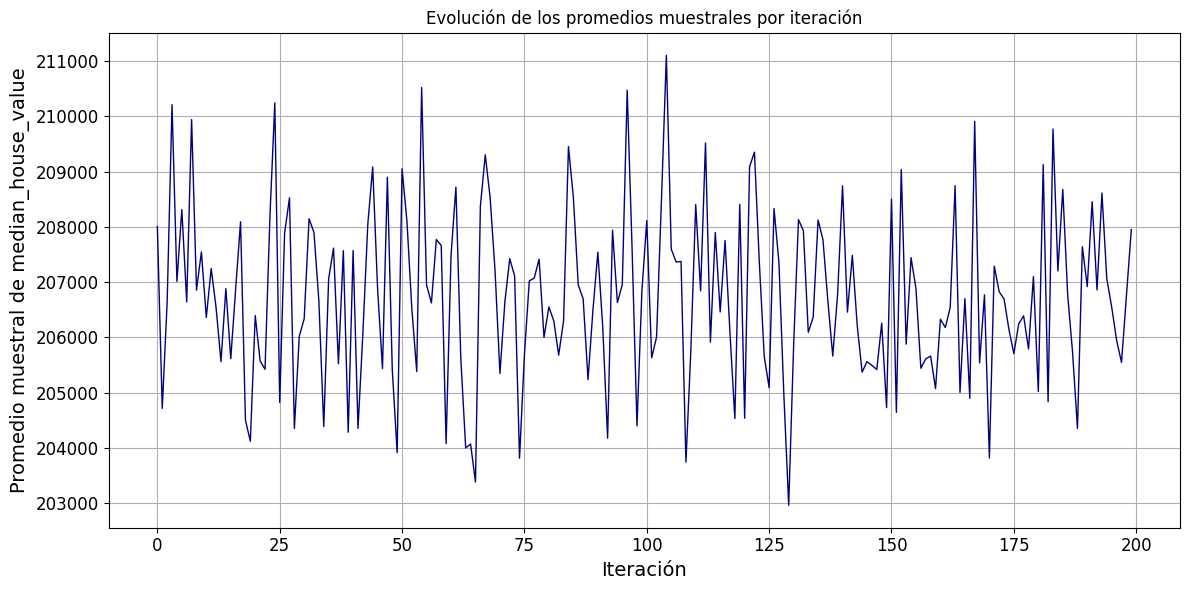

In [89]:
import matplotlib.pyplot as plt
import numpy as np

# Usar la lista ya generada previamente
promedios_linea = generar_lista_promedios(
    df=housing,
    porcentaje=0.3,
    iteraciones=200,
    columna='median_house_value',
    replace=True
)

# Crear gráfico de línea
plt.figure(figsize=(12, 6))
plt.plot(range(len(promedios_linea)), promedios_linea, color='navy', linewidth=1)

plt.title('Evolución de los promedios muestrales por iteración')
plt.xlabel('Iteración')
plt.ylabel('Promedio muestral de median_house_value')
plt.grid(True)
plt.tight_layout()
plt.show()


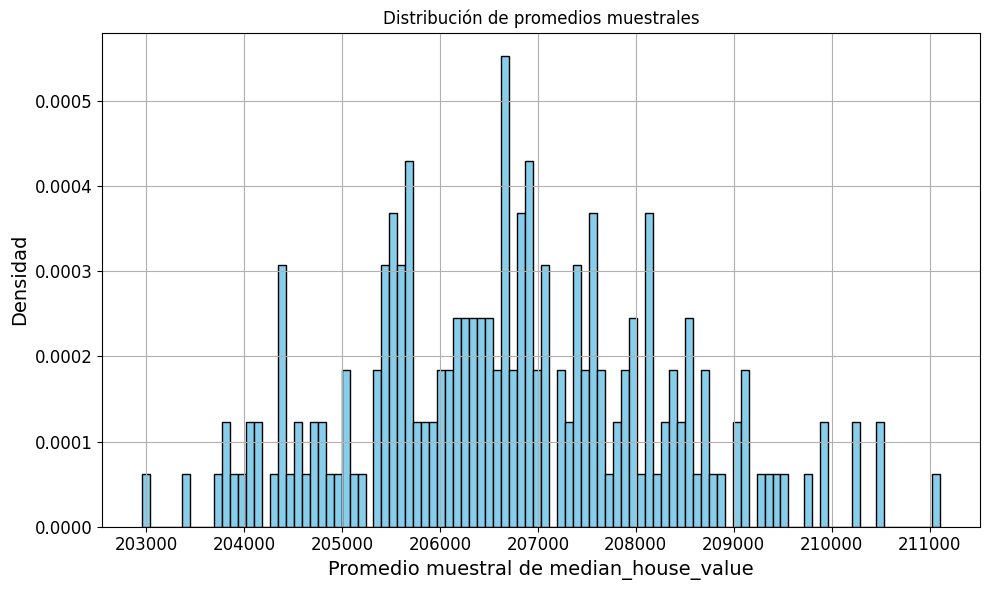

In [90]:
import matplotlib.pyplot as plt
import numpy as np

# Suponiendo que ya tienes esta lista:
# promedios_linea = generar_lista_promedios(...)

plt.figure(figsize=(10, 6))

# Usar la lista ya generada previamente
promedios_linea = generar_lista_promedios(
    df=housing,
    porcentaje=0.3,
    iteraciones=200,
    columna='median_house_value',
    replace=True
)

# Histograma con densidad (area total = 1)
plt.hist(promedios_linea, bins=100, density=True, color='skyblue', edgecolor='black')

plt.title('Distribución de promedios muestrales')
plt.xlabel('Promedio muestral de median_house_value')
plt.ylabel('Densidad')
plt.grid(True)
plt.tight_layout()
plt.show()


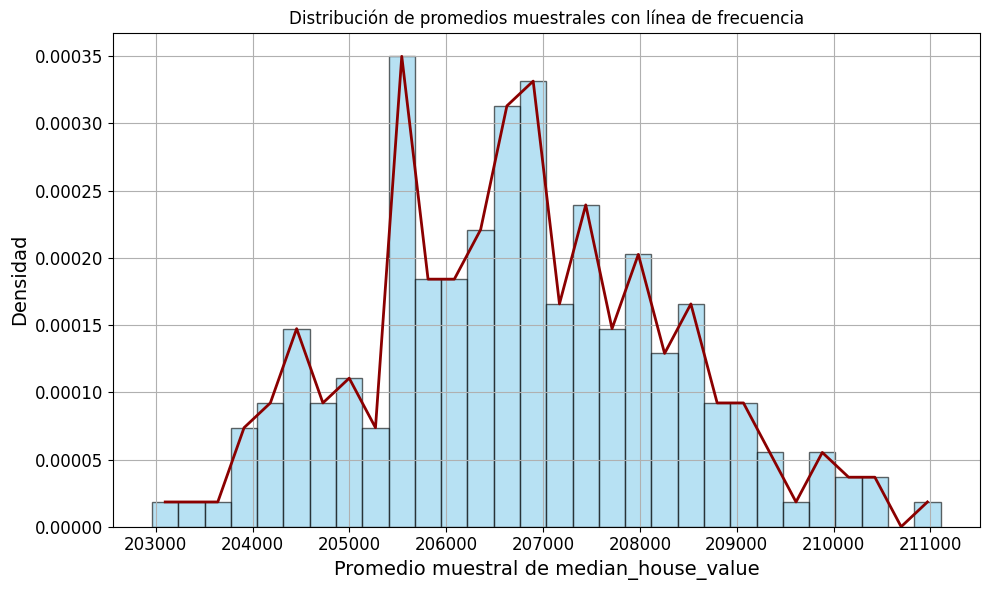

In [91]:
# Calcular histograma manualmente con numpy
counts, bins = np.histogram(promedios_linea, bins=30, density=True)

# Calcular los puntos medios de los bins para la curva
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Graficar
plt.figure(figsize=(10, 6))

# Histograma
plt.hist(promedios_linea, bins=30, density=True, color='skyblue', edgecolor='black', alpha=0.6)

# Línea que conecta los puntos medios
plt.plot(bin_centers, counts, color='darkred', linewidth=2)

plt.title('Distribución de promedios muestrales con línea de frecuencia')
plt.xlabel('Promedio muestral de median_house_value')
plt.ylabel('Densidad')
plt.grid(True)
plt.tight_layout()
plt.show()


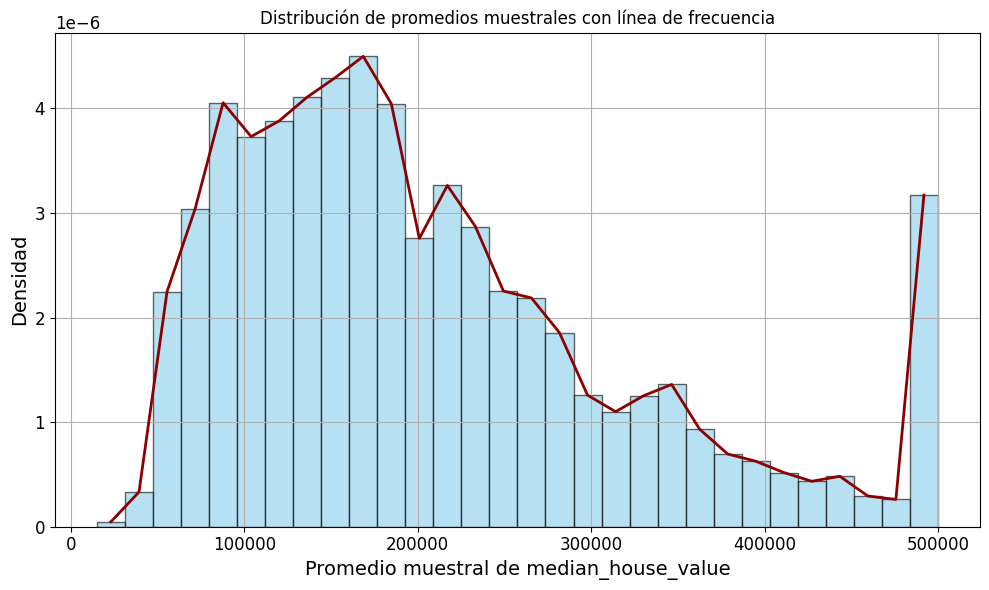

In [94]:
col = "median_house_value"
counts, bins = np.histogram(housing[col], bins=30, density=True)
# Calcular los puntos medios de los bins para la curva
bin_centers = 0.5 * (bins[:-1] + bins[1:])

# Graficar
plt.figure(figsize=(10, 6))

# Histograma
plt.hist(housing[col], bins=30, density=True, color='skyblue', edgecolor='black', alpha=0.6)

# Línea que conecta los puntos medios
plt.plot(bin_centers, counts, color='darkred', linewidth=2)

plt.title('Distribución de promedios muestrales con línea de frecuencia')
plt.xlabel('Promedio muestral de median_house_value')
plt.ylabel('Densidad')
plt.grid(True)
plt.tight_layout()
plt.show()

Saving figure long_tail_plot


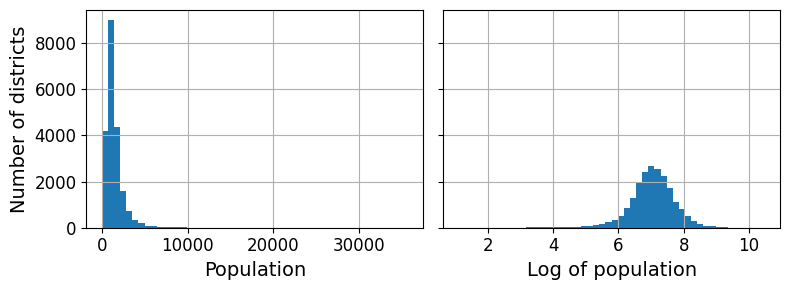

In [95]:
# extra code – this cell generates Figure 2–17
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing["population"].hist(ax=axs[0], bins=50)
housing["population"].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel("Population")
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")
save_fig("long_tail_plot")
plt.show()

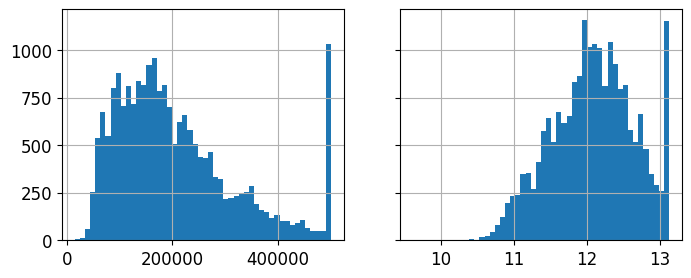

In [103]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
housing[col].hist(ax=axs[0], bins=50)
housing[col].apply(np.log).hist(ax=axs[1], bins=50)
# Usar la lista ya generada previamente
promedios_linea = generar_lista_promedios(
    df=housing,
    porcentaje=0.3,
    iteraciones=2000,
    columna=col,
    replace=True
)

# Histograma con densidad (area total = 1)
# plt.hist(promedios_linea, bins=100, density=True, color='skyblue', edgecolor='black')
plt.show()

In [105]:
# Gráfico doble, para comparación
# Original y gráfico final
import matplotlib.pyplot as plt
import pandas as pd

def compare_exclusion_effect(
    df: pd.DataFrame,
    exclude_values: list[float],
    x_col: str = "median_income",
    y_col: str = "median_house_value"
) -> None:
    """
    Muestra dos gráficos de dispersión lado a lado:
    - Izquierda: todos los datos.a
    - Derecha: sin los valores de y_col indicados en exclude_values.

    Parámetros:
    ----------
    df : pd.DataFrame
        Conjunto de datos.

    exclude_values : list[float]
        Lista de valores a excluir de y_col.

    x_col : str
        Columna para el eje X (por defecto 'median_income').

    y_col : str
        Columna para el eje Y (por defecto 'median_house_value').
    """

    # Crear subconjunto sin los valores excluidos
    filtered_df = df[~df[y_col].isin(exclude_values)]

    # Crear figura con dos ejes lado a lado
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

    # Gráfico 1: todos los datos
    df.plot(kind="scatter", x=x_col, y=y_col,
            alpha=0.1, grid=True, ax=axes[0])
    axes[0].set_title("Todos los datos")
    axes[0].set_xlabel(x_col)
    axes[0].set_ylabel(y_col)

    # Gráfico 2: sin valores excluidos
    filtered_df.plot(kind="scatter", x=x_col, y=y_col,
                     alpha=0.1, grid=True, ax=axes[1], color="green")
    axes[1].set_title(f"Sin valores: {exclude_values}")
    axes[1].set_xlabel(x_col)
    axes[1].set_ylabel("")  # Oculta etiqueta duplicada

    plt.tight_layout()
    plt.show()


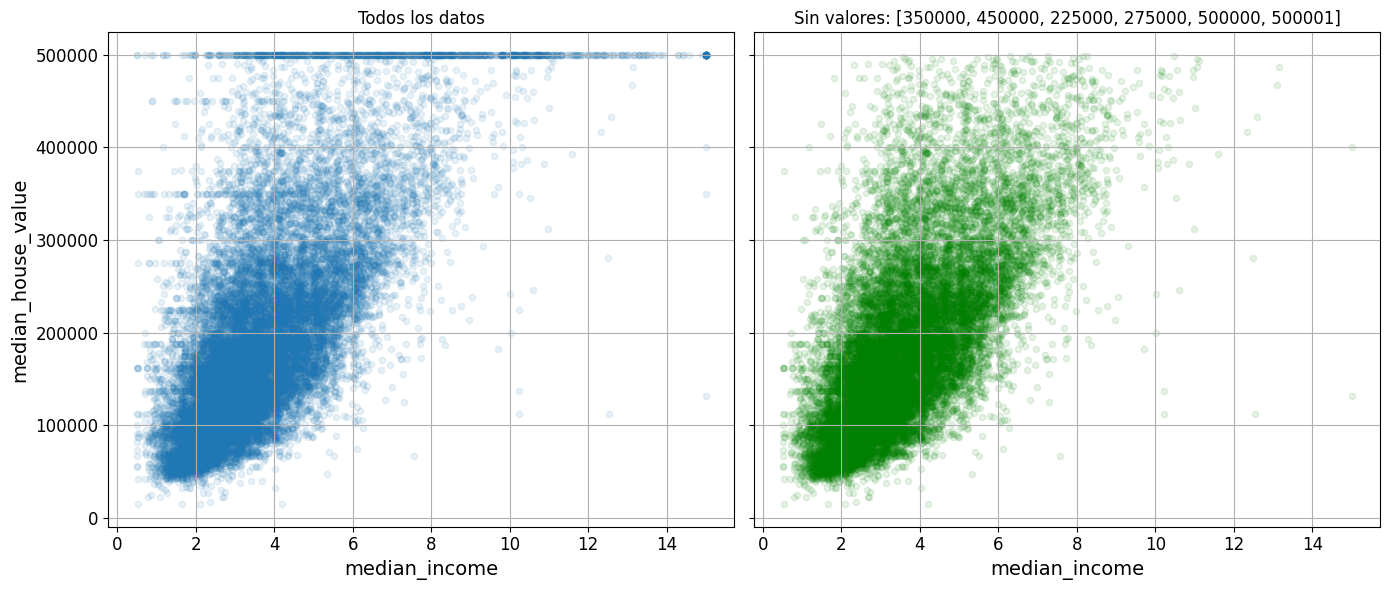

In [106]:
compare_exclusion_effect(df=housing, exclude_values=[350000, 450000, 225000, 275000, 500000, 500001])

In [108]:
filtered_df = housing[~housing[col].isin([350000, 450000, 225000, 275000, 500000, 500001])]

In [109]:
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 19375 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           19375 non-null  float64
 1   latitude            19375 non-null  float64
 2   housing_median_age  19375 non-null  float64
 3   total_rooms         19375 non-null  float64
 4   total_bedrooms      19176 non-null  float64
 5   population          19375 non-null  float64
 6   households          19375 non-null  float64
 7   median_income       19375 non-null  float64
 8   median_house_value  19375 non-null  float64
 9   ocean_proximity     19375 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


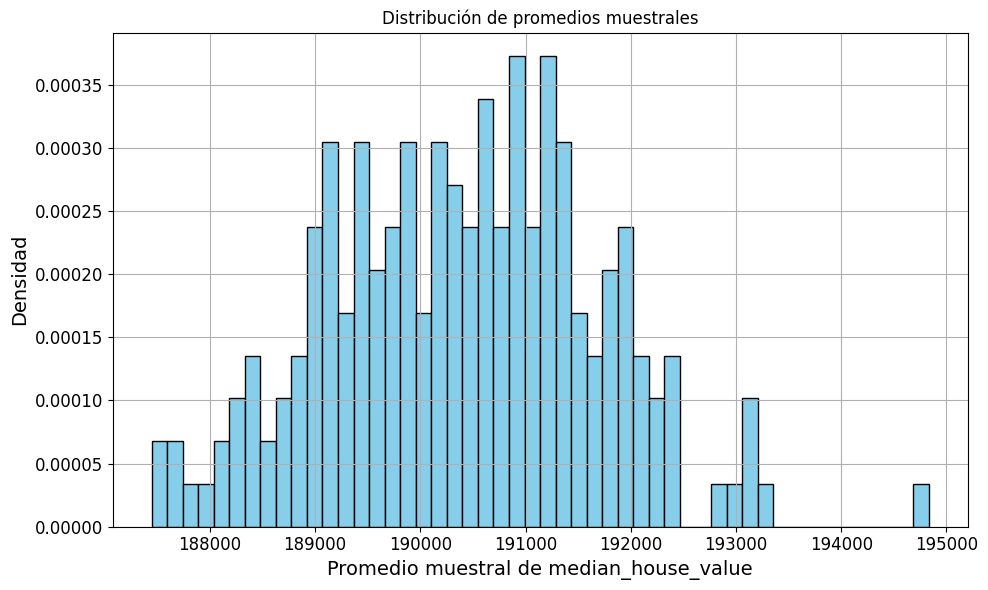

In [111]:
import matplotlib.pyplot as plt
import numpy as np

# Suponiendo que ya tienes esta lista:
# promedios_linea = generar_lista_promedios(...)

plt.figure(figsize=(10, 6))

# Usar la lista ya generada previamente
promedios_linea = generar_lista_promedios(
    df=filtered_df,
    porcentaje=0.3,
    iteraciones=200,
    columna='median_house_value',
    replace=True
)

# Histograma con densidad (area total = 1)
plt.hist(promedios_linea, bins=50, density=True, color='skyblue', edgecolor='black')

plt.title('Distribución de promedios muestrales')
plt.xlabel('Promedio muestral de median_house_value')
plt.ylabel('Densidad')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
filtered_df[col].hist()

Saving figure long_tail_plot


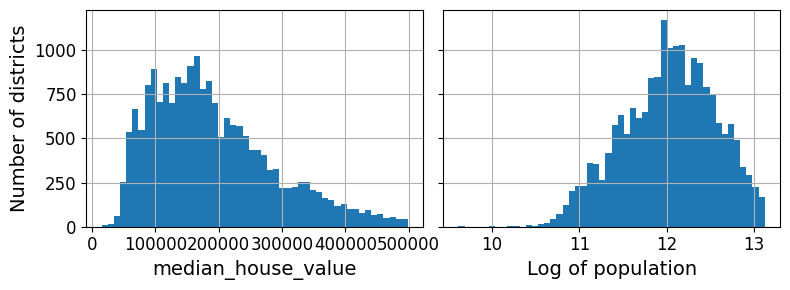

In [112]:
# extra code – this cell generates Figure 2–17
fig, axs = plt.subplots(1, 2, figsize=(8, 3), sharey=True)
filtered_df[col].hist(ax=axs[0], bins=50)
filtered_df[col].apply(np.log).hist(ax=axs[1], bins=50)
axs[0].set_xlabel(col)
axs[1].set_xlabel("Log of population")
axs[0].set_ylabel("Number of districts")
save_fig("long_tail_plot")
plt.show()

In [11]:
from sklearn.preprocessing import FunctionTransformer

log_transformer = FunctionTransformer(np.log, inverse_func=np.exp)
log_pop = log_transformer.transform(housing[["population"]])

In [17]:
from sklearn.metrics.pairwise import rbf_kernel

age_simil_35 = rbf_kernel(housing[["housing_median_age"]], [[35]], gamma=0.1)

In [23]:
import numpy as np

class MyFunctionTransformer:
    def __init__(self, func=None, inverse_func=None, validate=True):
        self.func = func if func is not None else lambda x: x
        self.inverse_func = inverse_func
        self.validate = validate

    def fit(self, X, y=None):
        # No se entrena nada, simplemente se retorna a sí mismo
        return self

    def transform(self, X):
        if self.validate:
            X = np.asarray(X)
            if X.ndim == 1:
                X = X.reshape(-1, 1)
        return self.func(X)

    def inverse_transform(self, X):
        if self.inverse_func is None:
            raise ValueError("inverse_func no está definida")
        return self.inverse_func(X)


In [51]:
log_transformer = MyFunctionTransformer(func=np.log1p, inverse_func=np.expm1)
X = np.array([[1], [10], [100]])
X_log = log_transformer.transform(X)
print(X_log)

[[0.69314718]
 [2.39789527]
 [4.61512052]]


In [52]:
X_orig = log_transformer.inverse_transform(X_log)
print(X_orig)

[[  1.]
 [ 10.]
 [100.]]


In [29]:
np.sin(100)

np.float64(-0.5063656411097588)

In [22]:
from sklearn.model_selection import StratifiedShuffleSplit

splitter = StratifiedShuffleSplit(n_splits=10, test_size=0.2, random_state=42)
strat_splits = []
for train_index, test_index in splitter.split(housing, housing["income_cat"]):
    strat_train_set_n = housing.iloc[train_index]
    strat_test_set_n = housing.iloc[test_index]
    strat_splits.append([strat_train_set_n, strat_test_set_n])

strat_train_set, strat_test_set = strat_splits[0] 

KeyError: 'income_cat'

In [ ]:
housing = strat_train_set.drop("median_house_value", axis=1)
housing_labels = strat_train_set["median_house_value"].copy()

In [16]:
from sklearn.linear_model import LinearRegression

target_scaler = StandardScaler()
scaled_labels = target_scaler.fit_transform(housing_labels.to_frame())

model = LinearRegression()
model.fit(housing[["median_income"]], scaled_labels)
some_new_data = housing[["median_income"]].iloc[:5]  # pretend this is new data

scaled_predictions = model.predict(some_new_data)
predictions = target_scaler.inverse_transform(scaled_predictions)

NameError: name 'housing_labels' is not defined

In [20]:
from sklearn.compose import TransformedTargetRegressor

model = TransformedTargetRegressor(LinearRegression(),
                                   transformer=StandardScaler())
model.fit(housing[["median_income"]], housing_labels)
predictions = model.predict(some_new_data)

NameError: name 'housing_labels' is not defined

In [53]:
rbf_transformer = FunctionTransformer(rbf_kernel,
                                      kw_args=dict(Y=[[35.]], gamma=0.1))
age_simil_35 = rbf_transformer.transform(housing[["housing_median_age"]])

In [54]:
age_simil_35

array([[2.73237224e-02],
       [3.07487988e-09],
       [2.81118530e-13],
       ...,
       [8.48904403e-15],
       [2.81118530e-13],
       [2.09879105e-16]], shape=(20640, 1))

In [62]:
from sklearn.metrics.pairwise import rbf_kernel
import numpy as np

X = np.array([[1.5], [2.0], [0.00000001]])
Y = np.array([[1.5]])

K = rbf_kernel(X, Y, gamma=0.9)
print(K)


[[1.        ]
 [0.79851622]
 [0.13199385]]


In [18]:
sf_coords = 37.7749, -122.41
sf_transformer = FunctionTransformer(rbf_kernel,
                                     kw_args=dict(Y=[sf_coords], gamma=0.1))
sf_simil = sf_transformer.transform(housing[["latitude", "longitude"]])

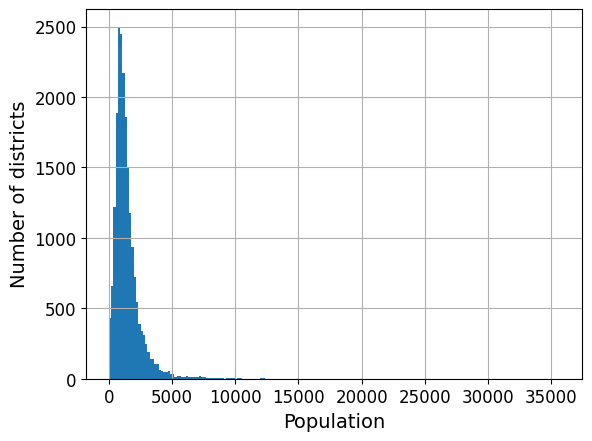

In [15]:
plt.hist(housing["population"], bins=200)
plt.grid()
plt.xlabel("Population")
plt.ylabel("Number of districts")
plt.show()

In [5]:
housing_num_log = housing.copy()
housing_num_log['log_population'] = np.log1p(housing_num_log['population'])

In [6]:
housing_num = housing_num_log.select_dtypes(include=[np.number])

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
housing_num_scaled = scaler.fit_transform(housing_num)

In [8]:
housing_num_scaled_df = pd.DataFrame(housing_num_scaled, columns=housing_num.columns, index=housing_num.index)

In [22]:
housing_num_scaled_df["ocean_proximity"] = housing["ocean_proximity"]

In [25]:
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


C:\Users\Elbert\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


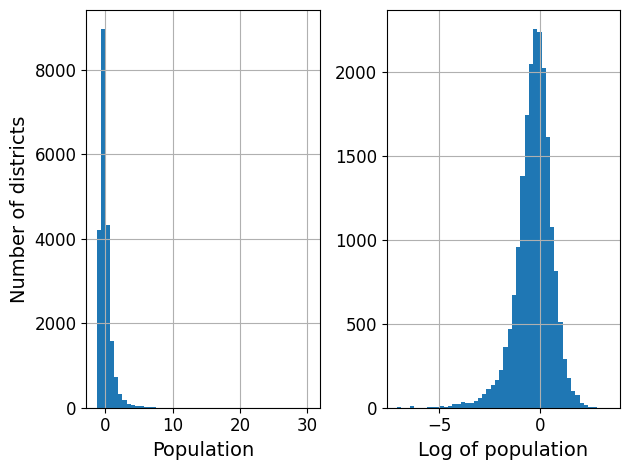

In [21]:
import matplotlib.pyplot as plt

plt.subplot(1, 2, 1)
housing_num_scaled_df["population"].hist(bins=50)
plt.xlabel("Population")
plt.ylabel("Number of districts")

plt.subplot(1, 2, 2)
np.log1p(housing_num_scaled_df["population"]).hist(bins=50)
plt.xlabel("Log of population")
plt.tight_layout()
plt.show()


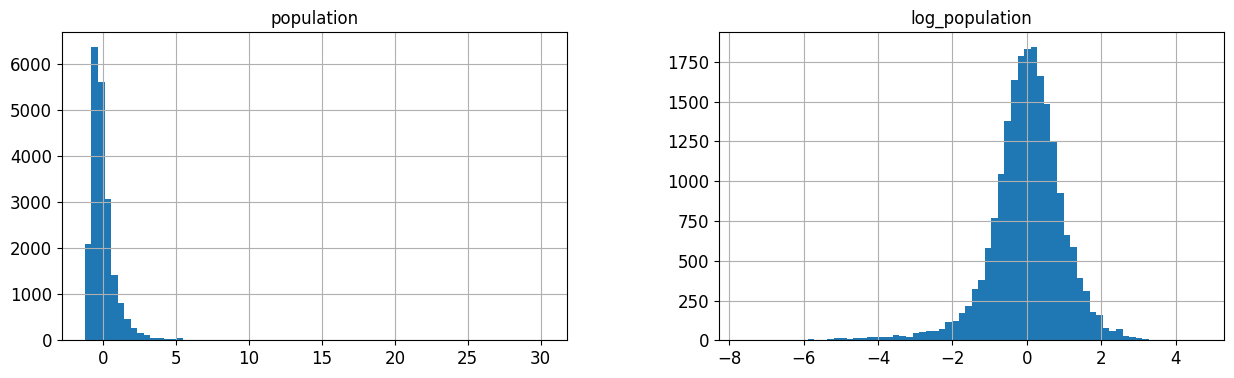

In [33]:
housing_num_scaled_df.hist(column=["population", "log_population"],
                           bins = 70, 
                           figsize = (15, 4))
plt.show()

In [29]:
housing_num_scaled_df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,log_population
count,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.043300e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04,2.064000e+04
mean,-8.526513e-15,-1.079584e-15,5.508083e-18,3.201573e-17,-7.233049e-17,-1.101617e-17,6.885104e-17,6.609700e-17,-9.363741e-17,-9.528984e-16
std,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00,1.000024e+00
min,-2.385992e+00,-1.447568e+00,-2.196180e+00,-1.207283e+00,-1.274093e+00,-1.256123e+00,-1.303984e+00,-1.774299e+00,-1.662641e+00,-7.659682e+00
25%,-1.113209e+00,-7.967887e-01,-8.453931e-01,-5.445698e-01,-5.740034e-01,-5.638089e-01,-5.742294e-01,-6.881186e-01,-7.561633e-01,-4.835575e-01
50%,5.389137e-01,-6.422871e-01,2.864572e-02,-2.332104e-01,-2.441308e-01,-2.291318e-01,-2.368162e-01,-1.767951e-01,-2.353337e-01,4.983434e-02
75%,7.784964e-01,9.729566e-01,6.643103e-01,2.348028e-01,2.589843e-01,2.644949e-01,2.758427e-01,4.593063e-01,5.014973e-01,5.814287e-01
max,2.625280e+00,2.958068e+00,1.856182e+00,1.681558e+01,1.401871e+01,3.025033e+01,1.460152e+01,5.858286e+00,2.540411e+00,4.695510e+00


In [30]:
housing.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


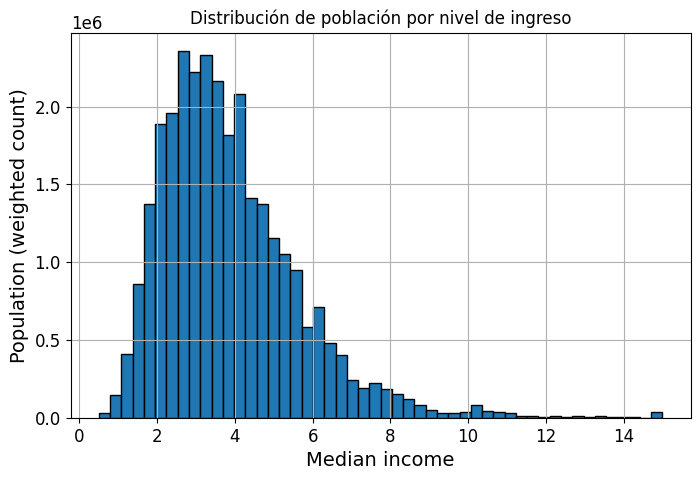

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    housing["median_income"],
    bins=50,
    weights=housing["population"],  # cada fila aporta su valor de población
    edgecolor="black"
)

plt.xlabel("Median income")
plt.ylabel("Population (weighted count)")
plt.title("Distribución de población por nivel de ingreso")
plt.grid(True)
plt.show()


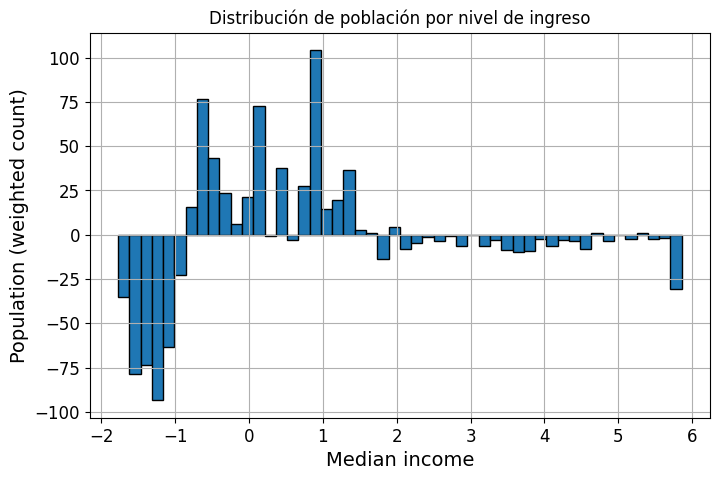

In [35]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    housing_num_scaled_df["median_income"],
    bins=50,
    weights=housing_num_scaled_df["population"],  # cada fila aporta su valor de población
    edgecolor="black"
)

plt.xlabel("Median income")
plt.ylabel("Population (weighted count)")
plt.title("Distribución de población por nivel de ingreso")
plt.grid(True)
plt.show()
